In [10]:
import pandas as pd

# Load the CSV
df = pd.read_excel("Coffee2019.xlsx")

# Combine 'Year' and 'Month' into a single datetime column
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# Set the new 'Date' column as index
df.set_index('Date', inplace=True)

# Optional: sort by date just to be safe
df.sort_index(inplace=True)

train = df[df.index.year < 2019]

test = df[df.index.year == 2019]

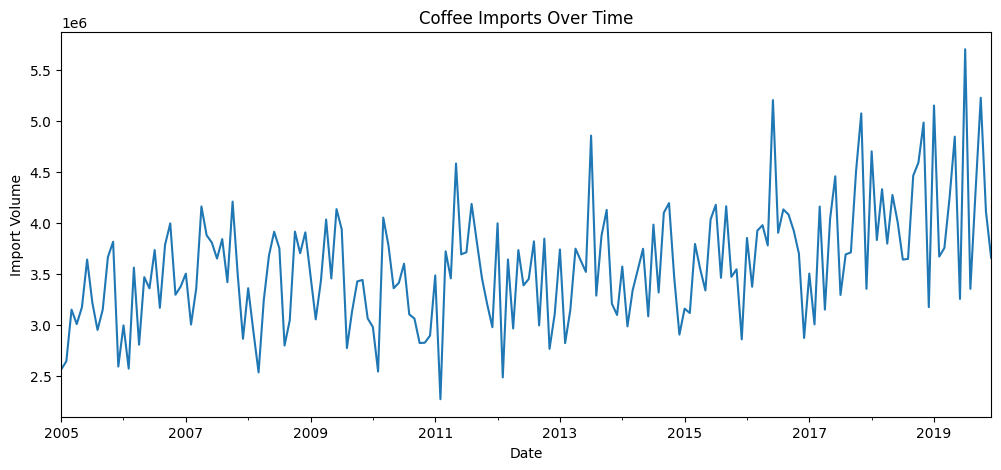

In [16]:
import matplotlib.pyplot as plt

df["Quantity"].plot(figsize=(12, 5), title="Coffee Imports Over Time")
plt.ylabel("Import Volume")
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_19100\3627209601.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['SMA_12'] = train['Quantity'].rolling(window=12).mean()


<Axes: title={'center': '12-Month Moving Average'}, xlabel='Date'>

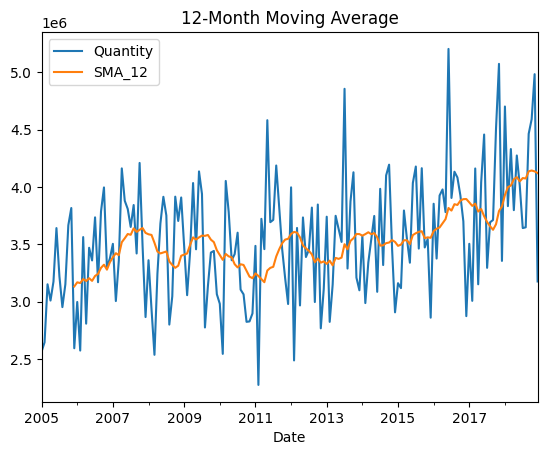

In [13]:
train['SMA_12'] = train['Quantity'].rolling(window=12).mean()
train[['Quantity', 'SMA_12']].plot(title="12-Month Moving Average")

C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Hp\AppData\Local\Temp\ipykernel_19100\3382682546.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['SES'] = model.fittedvalues


<Axes: title={'center': 'Single Exponential Smoothing'}, xlabel='Date'>

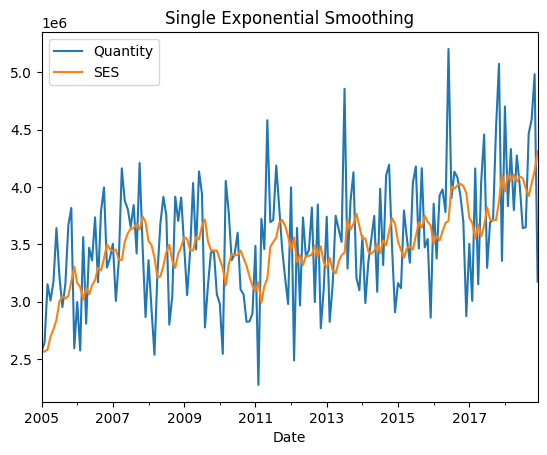

In [17]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

model = SimpleExpSmoothing(train['Quantity']).fit(smoothing_level=0.2, optimized=False)
train['SES'] = model.fittedvalues
train[['Quantity', 'SES']].plot(title="Single Exponential Smoothing")

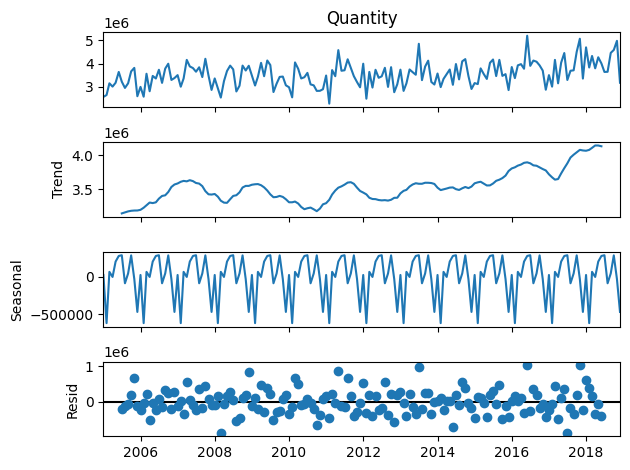

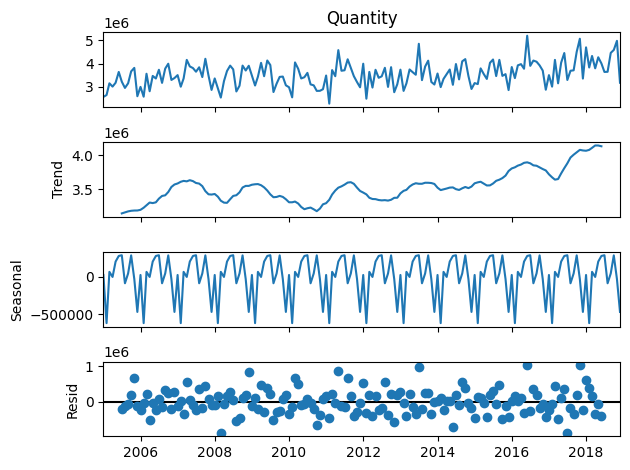

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(train['Quantity'], model='additive', period=12)
result.plot()

In [20]:
train['Seasonally_Adjusted'] = train['Quantity'] - result.seasonal

C:\Users\Hp\AppData\Local\Temp\ipykernel_19100\3245944817.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Seasonally_Adjusted'] = train['Quantity'] - result.seasonal


C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


<Axes: title={'center': 'Forecast for 2019'}>

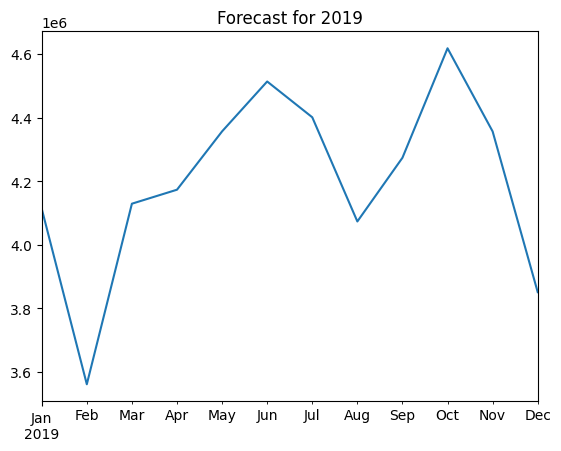

In [21]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(train['Quantity'], trend='add', seasonal='add', seasonal_periods=12)
fit = model.fit()
forecast = fit.forecast(steps=12)
forecast.plot(title="Forecast for 2019")